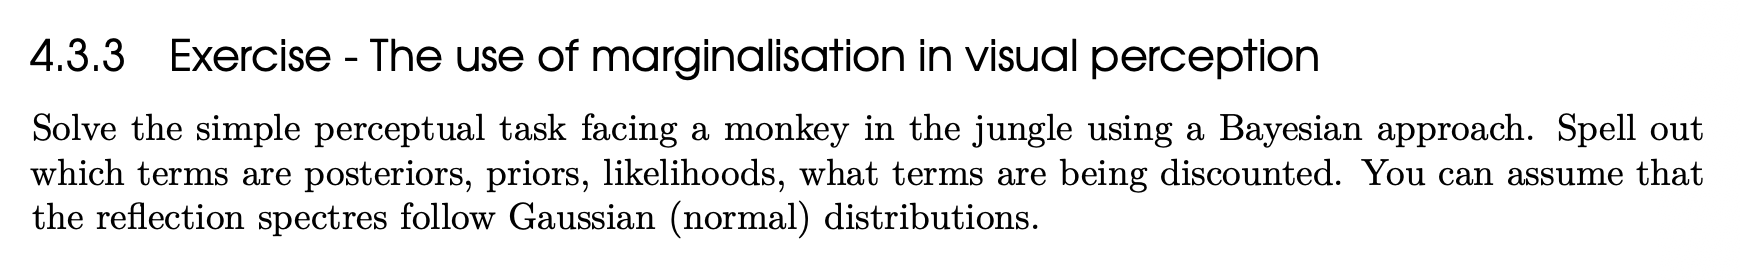

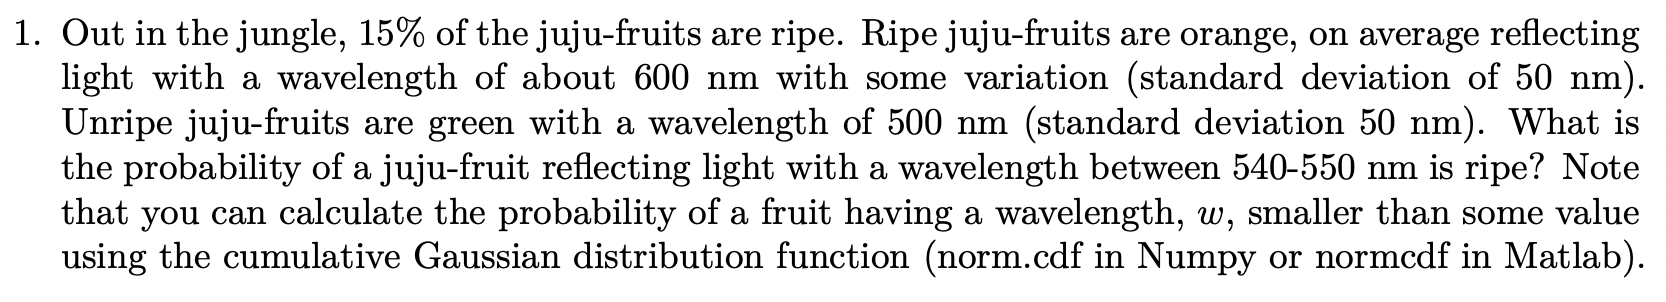

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

## Question 1 – Bayes' rule for a single fruit type

The state of the world is $w \in \{\text{ripe}, \text{unripe}\}$ and the sensory data $d$ is the event that the reflected wavelength $\lambda$ lies in the band $B = [540, 550]$ nm.

$$
\underbrace{P(\text{ripe} \mid B)}_{\text{posterior}} =
\frac{\overbrace{P(B \mid \text{ripe})}^{\text{likelihood}}\;\overbrace{P(\text{ripe})}^{\text{prior}}}
{\underbrace{P(B \mid \text{ripe})P(\text{ripe}) + P(B \mid \text{unripe})P(\text{unripe})}_{\text{evidence } P(B)}}
$$

* **Prior:** $P(\text{ripe}) = 0.15$, $P(\text{unripe}) = 0.85$, which is what the monkey knows before looking.
* **Likelihoods:** the reflection spectra are Gaussian, so the probability of a wavelength in the band is a difference of CDFs:
  $P(B \mid \text{ripe}) = \Phi\!\left(\tfrac{550-600}{50}\right) - \Phi\!\left(\tfrac{540-600}{50}\right)$, and likewise for unripe with $\mu = 500$.
* **Evidence:** $P(B)$ uses the law of total probability and only normalises the posterior so that $P(\text{ripe}\mid B) + P(\text{unripe}\mid B) = 1$.

In [2]:
band = (540, 550)

def p_band(mu, sigma, band=band):
    """Likelihood: probability that a Gaussian wavelength falls inside the band."""
    return norm.cdf(band[1], mu, sigma) - norm.cdf(band[0], mu, sigma)

# Prior
p_ripe = 0.15
p_unripe = 1 - p_ripe

# Likelihoods
L_ripe = p_band(600, 50)
L_unripe = p_band(500, 50)

# Evidence (normalisation)
evidence = L_ripe * p_ripe + L_unripe * p_unripe

# Posterior
post_ripe = L_ripe * p_ripe / evidence

print(f"Likelihood  P(B | ripe)   = {L_ripe:.4f}")
print(f"Likelihood  P(B | unripe) = {L_unripe:.4f}")
print(f"Evidence    P(B)          = {evidence:.4f}")
print(f"Posterior   P(ripe | B)   = {post_ripe:.4f}")

Likelihood  P(B | ripe)   = 0.0436
Likelihood  P(B | unripe) = 0.0532
Evidence    P(B)          = 0.0518
Posterior   P(ripe | B)   = 0.1263


**Answer:** $P(\text{ripe} \mid 540\text{–}550\,\text{nm}) \approx 0.126$.

The band lies about halfway between the two means, so the two likelihoods are almost equal (0.044 vs 0.053). The decision is therefore driven mainly by the prior: few juju-fruits are ripe, so the posterior stays low, slightly *below* the prior of 0.15 because unripe fruits are a little more likely to reflect in this band.

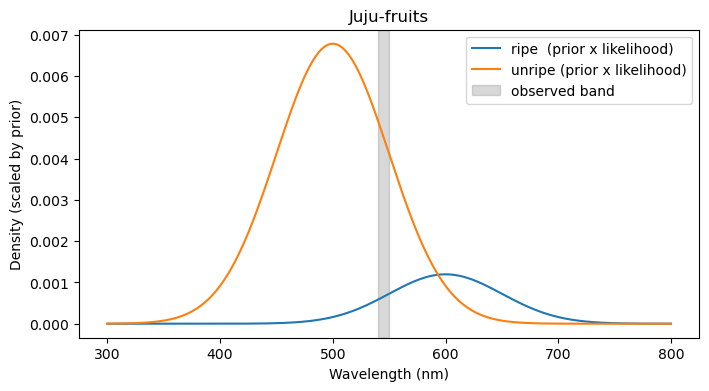

In [3]:
lam = np.linspace(300, 800, 1000)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lam, p_ripe * norm.pdf(lam, 600, 50), label='ripe  (prior x likelihood)')
ax.plot(lam, p_unripe * norm.pdf(lam, 500, 50), label='unripe (prior x likelihood)')
ax.axvspan(*band, color='grey', alpha=0.3, label='observed band')
ax.set_xlabel('Wavelength (nm)'); ax.set_ylabel('Density (scaled by prior)')
ax.set_title('Juju-fruits'); ax.legend()
plt.show()

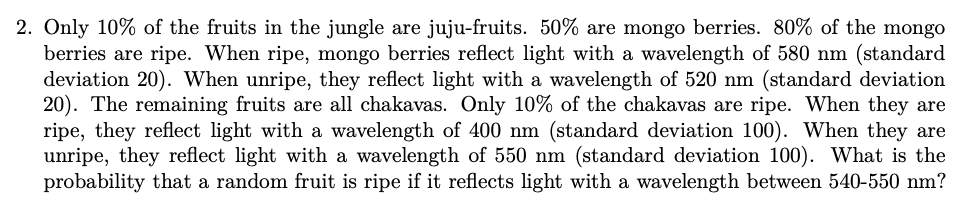

## Question 2 – Several fruit types: marginalisation over the nuisance variable

Only 10% of the fruits are juju-fruits, 50% are mongo berries and 40% are chakavas. The monkey only cares whether the fruit is **ripe**. It does not care which **fruit type** $f$ it is, so the fruit type is a *nuisance parameter*, as in Section 4.3 (where the lighting angle $w_2$ was integrated out to estimate the shape $w_1$). We split the world into $w_1 = $ ripeness and $w_2 = f$ and marginalise over $f$ (Eq. 4.6):

$$
P(\text{ripe} \mid B) = \sum_f P(\text{ripe}, f \mid B)
= \frac{\sum_f P(B \mid \text{ripe}, f)\, P(\text{ripe} \mid f)\, P(f)}
{\sum_f \sum_{r \in \{\text{ripe},\text{unripe}\}} P(B \mid r, f)\, P(r \mid f)\, P(f)}
$$

* **Posterior:** $P(\text{ripe} \mid B)$.
* **Priors:** the joint prior $P(r, f) = P(r \mid f)\,P(f)$, which combines the fruit frequencies $P(f)$ with the ripeness rate within each fruit, $P(\text{ripe} \mid f)$.
* **Likelihoods:** $P(B \mid r, f)$, the Gaussian band probabilities for each of the 6 fruit/ripeness combinations.
* **Discounted (marginalised) term:** the fruit type $f$, which is summed out.
* **Evidence:** the denominator, a normalising constant.

In [4]:
# fruit: (P(f), P(ripe | f), (mu, sigma) ripe, (mu, sigma) unripe)
fruits = {
    'juju':    (0.10, 0.15, (600, 50),  (500, 50)),
    'mongo':   (0.50, 0.80, (580, 20),  (520, 20)),
    'chakava': (0.40, 0.10, (400, 100), (550, 100)),
}

joint_ripe = 0.0    # sum_f P(B, ripe, f)
joint_all = 0.0     # sum_f sum_r P(B, r, f) = evidence P(B)
print(f"{'fruit':8s} {'P(B|ripe,f)':>12s} {'P(B|unripe,f)':>14s} {'P(B,ripe,f)':>12s} {'P(B,unripe,f)':>14s} {'P(ripe|B,f)':>12s}")
for name, (p_f, p_r, ripe, unripe) in fruits.items():
    a = p_band(*ripe) * p_r * p_f            # likelihood x prior, ripe
    b = p_band(*unripe) * (1 - p_r) * p_f    # likelihood x prior, unripe
    joint_ripe += a
    joint_all += a + b
    print(f"{name:8s} {p_band(*ripe):12.4f} {p_band(*unripe):14.4f} {a:12.5f} {b:14.5f} {a/(a+b):12.4f}")

post_ripe_all = joint_ripe / joint_all
print(f"\nEvidence  P(B)                         = {joint_all:.5f}")
print(f"Posterior P(ripe | B), f marginalised  = {post_ripe_all:.4f}")

# Posterior over fruit type given the band (what the monkey is implicitly weighing)
for name, (p_f, p_r, ripe, unripe) in fruits.items():
    pf_B = (p_band(*ripe) * p_r + p_band(*unripe) * (1 - p_r)) * p_f / joint_all
    print(f"P({name} | B) = {pf_B:.3f}")

fruit     P(B|ripe,f)  P(B|unripe,f)  P(B,ripe,f)  P(B,unripe,f)  P(ripe|B,f)
juju           0.0436         0.0532      0.00065        0.00452       0.1263
mongo          0.0441         0.0918      0.01762        0.00918       0.6574
chakava        0.0139         0.0398      0.00056        0.01434       0.0375

Evidence  P(B)                         = 0.04688
Posterior P(ripe | B), f marginalised  = 0.4018
P(juju | B) = 0.110
P(mongo | B) = 0.572
P(chakava | B) = 0.318


**Answer:** $P(\text{ripe} \mid 540\text{–}550\,\text{nm}) \approx 0.40$.

The marginal posterior is a mixture of the per-fruit posteriors (juju ≈ 0.13, mongo ≈ 0.66, chakava ≈ 0.04), weighted by how probable each fruit type is given the observed band, $P(f \mid B)$. Mongo berries are common and often ripe, which pulls the probability up. Chakavas are mostly unripe and their unripe spectrum (centred at 550 nm) fits the band well, which pulls it down.

The monkey does not need to identify the fruit to judge ripeness. Integrating over the nuisance variable gives one estimate that is robust to not knowing the fruit type. This is the same principle as integrating over the lighting angle in depth-from-shading (Section 4.3.1).